# DR mapped algal reads visualization

In [2]:
#load libraries
library(tidyverse)
library(vegan)
library(phyloseq)
library(ggplot2)
library(RColorBrewer)
library(DESeq2)
library(dplyr)

In [3]:
setwd("/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/DR/kraken_bracken/symbionts")

In [31]:
data <- read.csv("mapped_algal_symb_reads.csv", header = TRUE)

In [32]:
head (data)

,Sample,Durusdinium_trenchii,Cladocopium_goreaui,Breviolum_minutum,Cladocopium_sp.,Host,Colony_tag,Sample_type
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
1,122021_Coralina_2021_Baya_021_SSID2_S36,0.000000,0.0000000,2.642223,0.0000000,SSID,SSID-2,Healthy
2,122021_Coralina_2021_Baya_019_SSID1_S46,61.122370,1.6294729,0.179602,0.0000000,SSID,SSID-1,Healthy
3,072023_Carolina_2023_Baya_063_SSID_S6,6.708660,2.4369505,0.000000,0.0000000,SSID,SSID-1,Disease_margin
4,072023_Carolina_2023_Baya_061_SSID_S5,4.601157,0.6527612,0.000000,0.0000000,SSID,SSID-1,Disease_tissue
5,072023_Carolina_2023_Baya_059_SSID_S8,0.000000,1.3485426,0.000000,0.0000000,SSID,SSID-2,Disease_margin
6,072023_Carolina_2023_Baya_057_SSID_S7,0.000000,1.6827066,0.000000,0.1118864,SSID,SSID-2,Disease_tissue


In [34]:
data_pivoted <- data %>%
    pivot_longer(-c(Sample, Host, Sample_type, Colony_tag), names_to = "Symbiont", values_to = c("Percent_reads"))
head(data_pivoted)

Sample,Host,Colony_tag,Sample_type,Symbiont,Percent_reads
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
122021_Coralina_2021_Baya_021_SSID2_S36,SSID,SSID-2,Healthy,Durusdinium_trenchii,0.000000
122021_Coralina_2021_Baya_021_SSID2_S36,SSID,SSID-2,Healthy,Cladocopium_goreaui,0.000000
122021_Coralina_2021_Baya_021_SSID2_S36,SSID,SSID-2,Healthy,Breviolum_minutum,2.642223
122021_Coralina_2021_Baya_021_SSID2_S36,SSID,SSID-2,Healthy,Cladocopium_sp.,0.000000
122021_Coralina_2021_Baya_019_SSID1_S46,SSID,SSID-1,Healthy,Durusdinium_trenchii,61.122370
122021_Coralina_2021_Baya_019_SSID1_S46,SSID,SSID-1,Healthy,Cladocopium_goreaui,1.629473


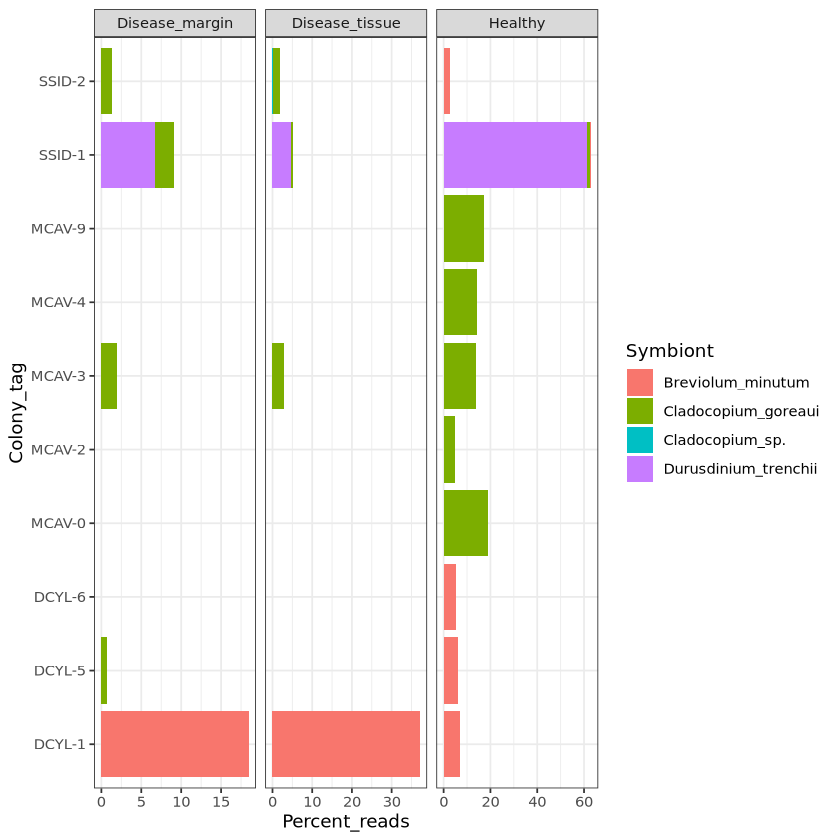

In [37]:
plot <- ggplot(data_pivoted, aes(x = Colony_tag, y = Percent_reads, fill = Symbiont)) +
  geom_bar(stat= "identity", position = "stack")+
  facet_grid(~Sample_type, scales="free_x")+
  coord_flip() +
theme_bw()
plot

In [45]:
options(repr.plot.width=10, repr.plot.height=10)

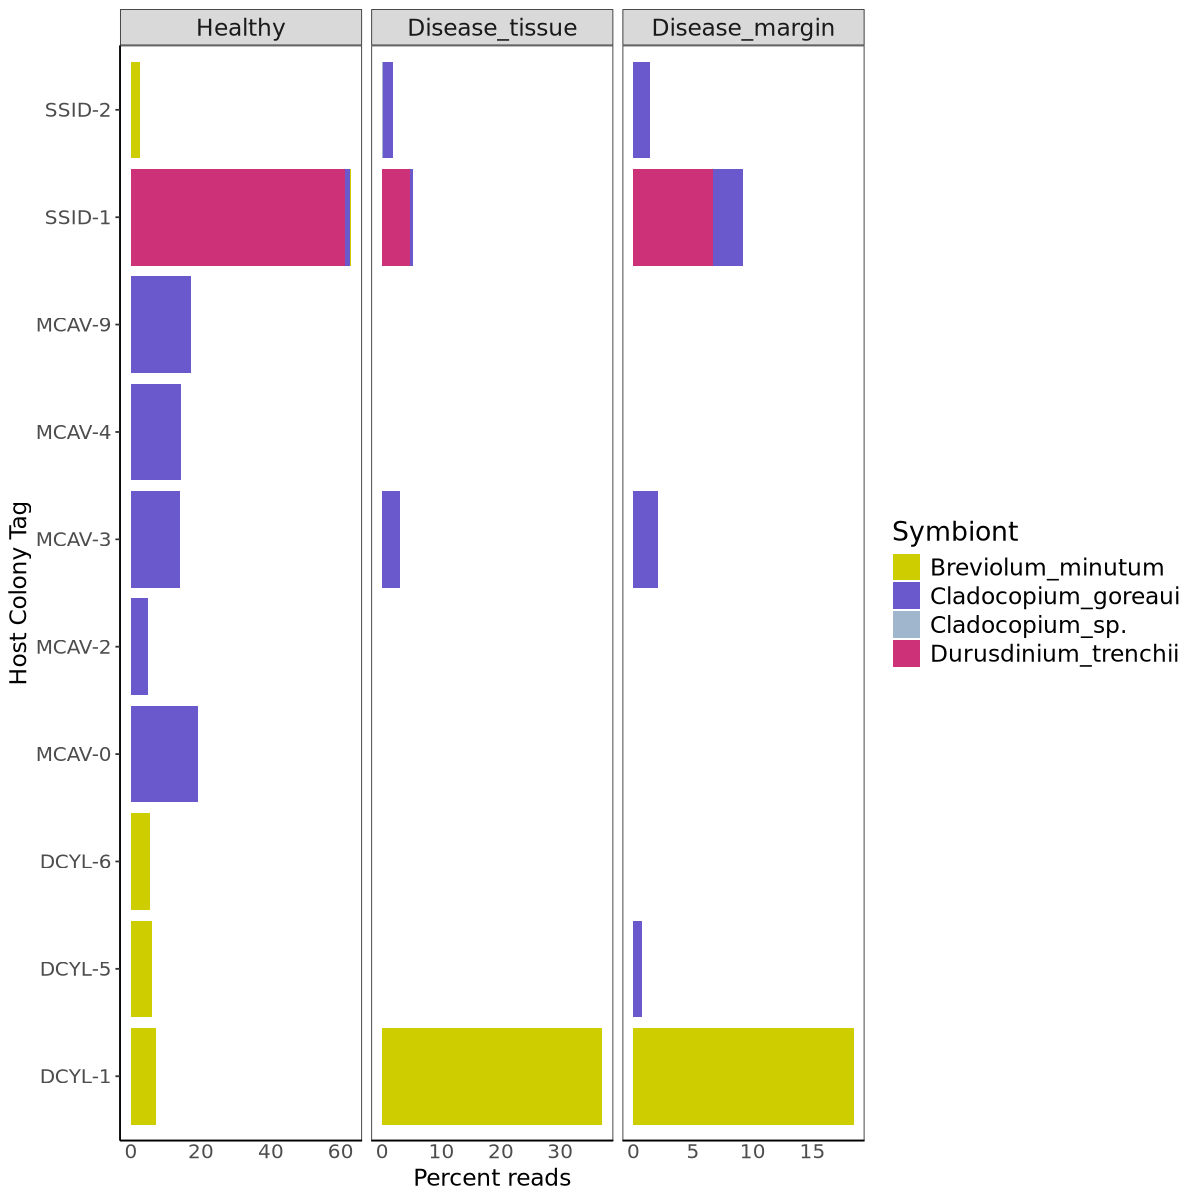

In [47]:
#make prettier
plot1 <- ggplot(data_pivoted, aes(x = Colony_tag, y = Percent_reads, fill = Symbiont)) +
  geom_bar(stat= "identity", position = "stack")+
  facet_grid(~ factor(Sample_type, levels=c("Healthy", "Disease_tissue", "Disease_margin")), scales="free_x")+
  coord_flip() +
theme_bw() +
theme(panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          panel.grid.major.y = element_blank(),
          panel.grid.minor.y = element_blank(),
          axis.text.x = element_text(size = 12),
          axis.text.y = element_text(size = 12),  # Adjust y-axis text size
          axis.title.x = element_text(size = 14),  # Adjust x-axis title size and margin
          axis.title.y = element_text(size = 14),
          strip.text = element_text(size = 14),
          legend.title = element_text(size = 16),
          legend.text = element_text(size = 14),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"))+
scale_fill_manual(values= c("Cladocopium_goreaui"="slateblue3", "Breviolum_minutum"="yellow3", "Durusdinium_trenchii"="violetred3", "Cladocopium_sp."="slategray3"))+
labs(x = "Host Colony Tag", y = "Percent reads", fill = "Symbiont") 
plot1

In [48]:
ggsave(filename = "Mapped_symbionts_plot.png", plot = plot1, 
      width = 10,
      height = 10,
      units = "in",
      dpi = 300)

## percents of just symbiont reads

In [5]:
data1 <- read.csv("algal_symb_reads_only_ready.csv", header = TRUE)
head (data1)

,Sample,Durusdinium_trenchii,Cladocopium_goreaui,Breviolum_minutum,Cladocopium_sp.,Symbiodinium_kawagutii,Host,Colony_tag,Sample_type
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
1,122021_Coralina_2021_Baya_021_SSID2_S36,0.00000,1.327080,75.15236,0.000000,0,SSID,SSID-2,Healthy
2,122021_Coralina_2021_Baya_019_SSID1_S46,84.00054,2.239388,0.00000,0.000000,0,SSID,SSID-1,Healthy
3,072023_Carolina_2023_Baya_063_SSID_S6,43.63925,15.851784,0.00000,0.000000,0,SSID,SSID-1,Disease_margin
4,072023_Carolina_2023_Baya_061_SSID_S5,46.90317,6.673089,0.00000,0.000000,0,SSID,SSID-1,Disease_tissue
5,072023_Carolina_2023_Baya_059_SSID_S8,0.00000,24.662330,0.00000,1.735246,0,SSID,SSID-2,Disease_margin
6,072023_Carolina_2023_Baya_057_SSID_S7,0.00000,26.670155,0.00000,1.741188,0,SSID,SSID-2,Disease_tissue


In [6]:
data1_pivoted <- data1 %>%
    pivot_longer(-c(Sample, Host, Sample_type, Colony_tag), names_to = "Symbiont", values_to = c("Percent_algal_reads"))
head(data1_pivoted)

Sample,Host,Colony_tag,Sample_type,Symbiont,Percent_algal_reads
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
122021_Coralina_2021_Baya_021_SSID2_S36,SSID,SSID-2,Healthy,Durusdinium_trenchii,0.00000
122021_Coralina_2021_Baya_021_SSID2_S36,SSID,SSID-2,Healthy,Cladocopium_goreaui,1.32708
122021_Coralina_2021_Baya_021_SSID2_S36,SSID,SSID-2,Healthy,Breviolum_minutum,75.15236
122021_Coralina_2021_Baya_021_SSID2_S36,SSID,SSID-2,Healthy,Cladocopium_sp.,0.00000
122021_Coralina_2021_Baya_021_SSID2_S36,SSID,SSID-2,Healthy,Symbiodinium_kawagutii,0.00000
122021_Coralina_2021_Baya_019_SSID1_S46,SSID,SSID-1,Healthy,Durusdinium_trenchii,84.00054


In [7]:
options(repr.plot.width=10, repr.plot.height=10)

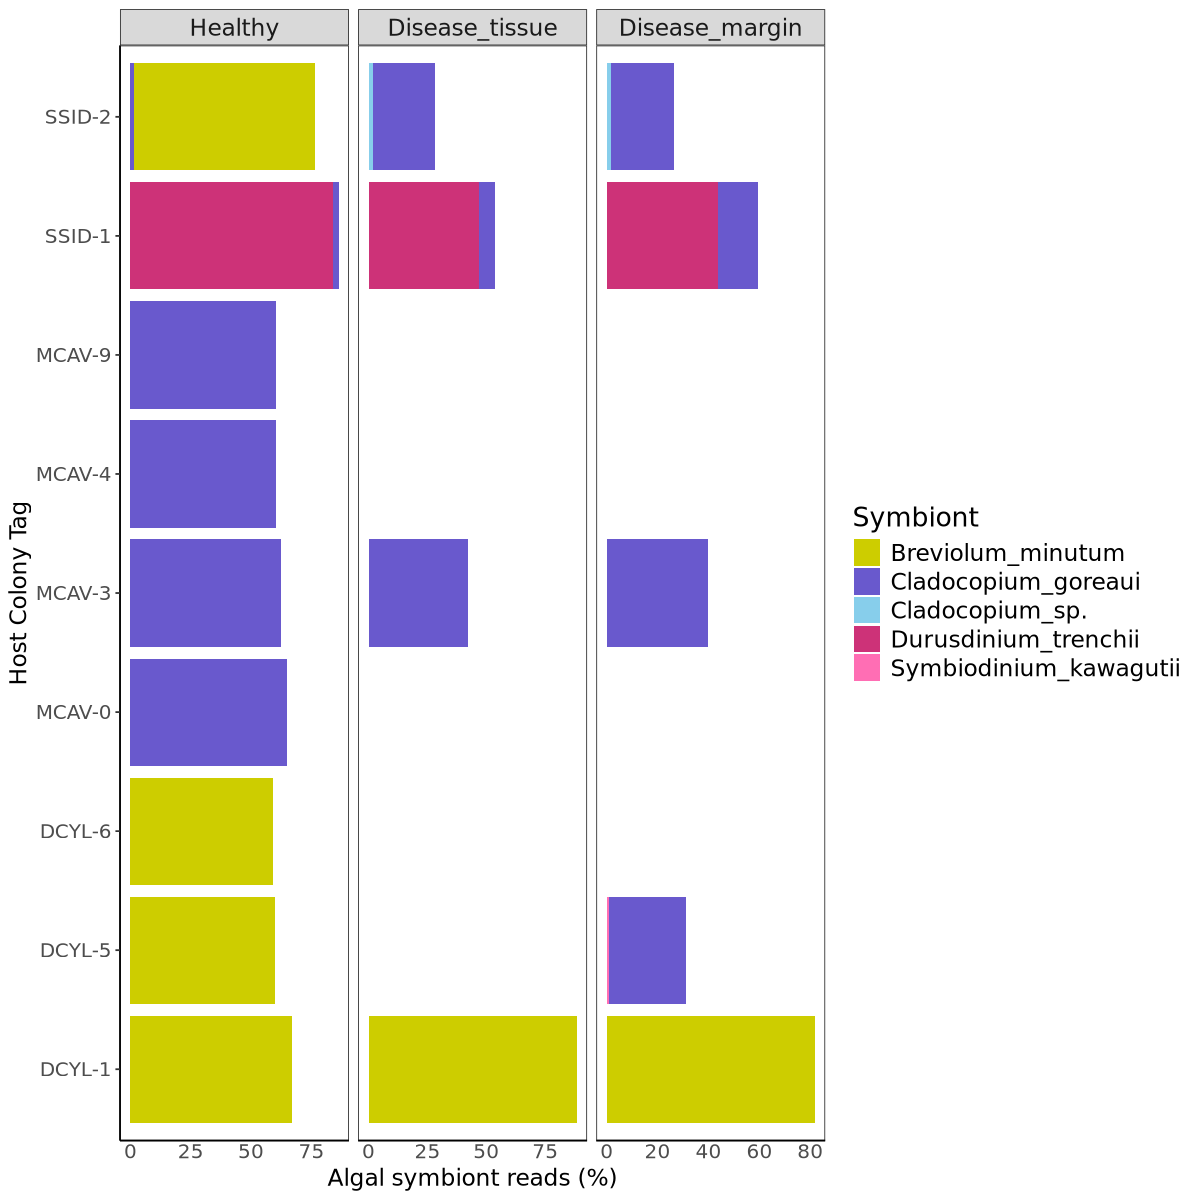

In [11]:
#make prettier
plot_symb <- ggplot(data1_pivoted, aes(x = Colony_tag, y = Percent_algal_reads, fill = Symbiont)) +
  geom_bar(stat= "identity", position = "stack")+
  facet_grid(~ factor(Sample_type, levels=c("Healthy", "Disease_tissue", "Disease_margin")), scales="free_x")+
  coord_flip() +
theme_bw() +
theme(panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          panel.grid.major.y = element_blank(),
          panel.grid.minor.y = element_blank(),
          axis.text.x = element_text(size = 12),
          axis.text.y = element_text(size = 12),  # Adjust y-axis text size
          axis.title.x = element_text(size = 14),  # Adjust x-axis title size and margin
          axis.title.y = element_text(size = 14),
          strip.text = element_text(size = 14),
          legend.title = element_text(size = 16),
          legend.text = element_text(size = 14),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"))+
scale_fill_manual(values= c("Cladocopium_goreaui"="slateblue3", "Breviolum_minutum"="yellow3", "Durusdinium_trenchii"="violetred3", 
                            "Cladocopium_sp."="skyblue", "Symbiodinium_kawagutii"="hotpink1"))+
labs(x = "Host Colony Tag", y = "Algal symbiont reads (%)", fill = "Symbiont") 
plot_symb

In [12]:
ggsave(filename = "Symbionts_plot_better.png", plot = plot_symb, 
      width = 10,
      height = 10,
      units = "in",
      dpi = 300)

should gray out areas with no sample information (in case its confusing), to do this could add those samples to tabe with values of NA, then something like: scale_fill_viridis_c(na.value = "gray80")